In [89]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor

# Loading data

In [90]:
df = pd.read_parquet('../data/processed/feature_engineered.parquet')

In [91]:
df_dashboard = df.copy()

In [92]:
pd.set_option('display.max_columns', None)

# Temporary Checking Feature Importance

In [93]:
df_sample = df.sample(frac=0.2, random_state=42)

drop_cols = [
    'order_id', 'customer_id',
    'product_id', 'seller_id',
    'customer_city',
    'customer_zip_code_prefix',
    'order_status',
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_timestamp',
    'order_estimated_delivery_date'
    
]

df_sample = df_sample.drop(columns=drop_cols)

low_card_cols = ['payment_type', 'customer_state', 'product_category_name']
df_sample = pd.get_dummies(df_sample, columns=low_card_cols, drop_first=True)

df_sample = df_sample.copy()

X = df_sample.drop(columns=['log_payment_value', 'payment_value'])
y = df_sample['log_payment_value']

model = XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    tree_method="hist",
    device="cuda",
    random_state=42
)

model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

print(importance.head(20))

product_category_name_computers_accessories                      0.043538
product_category_name_garden_tools                               0.035189
product_category_name_construction_tools_construction            0.026993
product_category_name_industry_commerce_and_business             0.023445
customer_state_SP                                                0.023251
payment_type_debit_card                                          0.022558
customer_state_GO                                                0.022150
total_cost                                                       0.021166
shipping_ratio                                                   0.020406
customer_state_CE                                                0.018901
product_category_name_kitchen_dining_laundry_garden_furniture    0.018677
product_category_name_perfumery                                  0.018650
product_category_name_pet_shop                                   0.018613
product_width_cm                      

# Insighs

- Important

product_category_name_* → VERY important

payment_type_* → important

customer_state_* → important

total_cost → important

shipping_ratio → important

product features (height, volume, density) → useful

- Not Important

price

payment_value components directly

most time features

city (we dropped — good decision)

In [94]:
top_categories = df['product_category_name'].value_counts().nlargest(10).index
df['top_category'] = df['product_category_name'].isin(top_categories).astype(int)

### Droping UnImportant Columns

drop_cols = [
    'order_id', 'customer_id',
    'product_id', 'seller_id',
    'customer_city',
    'customer_zip_code_prefix',
    'order_status',
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_timestamp',
    'order_estimated_delivery_date'
]

df_model = df.drop(columns=drop_cols)

In [95]:
drop_cols = [
    'order_id', 'customer_id',
    'product_id', 'seller_id',
    'customer_city',
    'customer_zip_code_prefix',
    'order_status',
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_timestamp',
    'order_estimated_delivery_date'
]

df_model = df.drop(columns=drop_cols)

In [96]:
X = df_model.drop(columns=['payment_value', 'log_payment_value'])
y = df_model['log_payment_value']

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87413 entries, 0 to 87412
Data columns (total 42 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       87413 non-null  category      
 1   customer_id                    87413 non-null  category      
 2   order_status                   87413 non-null  category      
 3   order_purchase_timestamp       87413 non-null  datetime64[ns]
 4   order_approved_at              87413 non-null  datetime64[ns]
 5   order_delivered_timestamp      87413 non-null  datetime64[ns]
 6   order_estimated_delivery_date  87413 non-null  datetime64[ns]
 7   payment_sequential             87413 non-null  int64         
 8   payment_type                   87413 non-null  category      
 9   payment_installments           87413 non-null  int16         
 10  payment_value                  87413 non-null  float64       
 11  product_id     

In [98]:
df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,payment_sequential,payment_installments,payment_value,price,shipping_charges,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_volume_cm3,delivery_time_days,approval_time_hours,delivery_delay_days,total_cost,shipping_ratio,product_density,order_month,order_dayofweek,is_weekend,log_delivery_time,log_shipping_ratio,price_bucket,high_shipping,is_expensive,is_large_product,high_installments,log_payment_value,top_category
count,87413,87413,87413,87413,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000
mean,2017-12-29 22:08:00.051639808,2017-12-30 08:30:16.404482048,2018-01-11 08:33:03.465502976,2018-01-22 18:57:26.837426944,1.097400,2.963987,268.788524,342.292224,44.244648,2081.968750,30.199352,16.528275,23.026655,15178.513539,11.968689,10.292836,-12.012367,386.536872,0.826308,0.182799,6.032856,2.746182,0.225641,2.363521,0.368378,1.982039,0.293869,0.499685,0.499743,0.288424,5.045839,0.908503
min,2016-10-03 09:44:50,2016-10-04 09:43:32,2016-10-11 13:46:32,2016-10-27 00:00:00,1.000000,0.000000,0.000000,0.850000,0.000000,2.000000,7.000000,2.000000,6.000000,168.000000,0.000000,0.000000,-30.000000,1.140000,0.000000,0.000318,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2017-09-10 20:15:46,2017-09-11 15:30:18,2017-09-20 20:27:47,2017-10-02 00:00:00,1.000000,1.000000,84.330000,59.650000,20.040000,300.000000,18.000000,8.000000,15.000000,2856.000000,6.000000,0.215278,-17.000000,107.720000,0.072984,0.067200,3.000000,1.000000,0.000000,1.945910,0.070443,1.000000,0.000000,0.000000,0.000000,0.000000,4.446526,1.000000
50%,2018-01-17 11:59:12,2018-01-17 16:35:21,2018-01-30 22:48:40,2018-02-14 00:00:00,1.000000,2.000000,171.860000,136.900000,35.010000,700.000000,25.000000,13.000000,20.000000,6555.000000,10.000000,0.344722,-13.000000,184.750000,0.221800,0.112000,6.000000,3.000000,0.000000,2.397895,0.200325,2.000000,0.000000,0.000000,0.000000,0.000000,5.152482,1.000000
75%,2018-05-02 23:06:51,2018-05-03 09:12:19,2018-05-14 15:54:50,2018-05-24 00:00:00,1.000000,4.000000,313.550000,399.200000,57.150000,1800.000000,38.000000,20.000000,30.000000,18375.000000,15.000000,14.833056,-7.000000,438.450000,0.607091,0.191250,8.000000,4.000000,0.000000,2.772589,0.474425,3.000000,1.000000,1.000000,1.000000,1.000000,5.751143,1.000000
max,2018-08-29 14:52:00,2018-08-29 15:05:22,2018-10-17 13:22:46,2018-10-25 00:00:00,26.000000,24.000000,7274.880000,6735.000000,409.680000,40425.000000,105.000000,105.000000,118.000000,294000.000000,209.000000,168.000000,30.000000,6738.820000,205.279938,10.000000,12.000000,6.000000,1.000000,5.347108,5.329234,4.000000,1.000000,1.000000,1.000000,1.000000,8.892320,1.000000
std,NaN,NaN,NaN,NaN,0.742207,2.794934,344.834902,559.776730,37.657927,3734.926025,16.051746,13.366062,11.670736,23139.189494,9.277935,19.754494,8.934977,560.813861,4.051982,0.353039,3.231184,1.957856,0.418006,0.634378,0.479195,1.401218,0.455535,0.500003,0.500003,0.453032,1.134738,0.288316


# Model 0 Training - Product Value Prediction

## TRAIN-TEST SPLIT

In [99]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [100]:
categorical_cols = [
    'payment_type',
    'customer_state',
    'product_category_name'
]

X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

### XGBoost

In [101]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    device="cuda",   # remove if no GPU
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabete

In [102]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_log = model.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 177.29401172661724
RMSE: 354.89779057875614
R2 Score: -0.06298737837697099


### Linear Regression

In [103]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = np.expm1(lr.predict(X_test))

print("LR R2:", r2_score(y_true, y_pred))

LR R2: -0.11055726796232968


### Random Forest

In [104]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = np.expm1(rf.predict(X_test))

print("RF R2:", r2_score(y_true, y_pred))

RF R2: -0.0754231605896376


### XGBoost Tuned

In [105]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred = np.expm1(xgb.predict(X_test))

print("XGB R2:", r2_score(y_true, y_pred))

XGB R2: -0.06438315443553821


### LightGBM

In [106]:
from lightgbm import LGBMRegressor

lgb = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

lgb.fit(X_train, y_train)

y_pred = np.expm1(lgb.predict(X_test))

print("LGBM R2:", r2_score(y_true, y_pred))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006853 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3065
[LightGBM] [Info] Number of data points in the train set: 69930, number of used features: 104
[LightGBM] [Info] Start training from score 5.042887
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

# Insights
Model is not giving accurate results, so we change the objective
- High Value Order Prediction
- Delivery Delay Prediction

In [107]:
df_model.head()

,payment_sequential,payment_type,payment_installments,payment_value,price,shipping_charges,customer_state,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_volume_cm3,delivery_time_days,approval_time_hours,delivery_delay_days,total_cost,shipping_ratio,product_density,order_month,order_dayofweek,is_weekend,log_delivery_time,log_shipping_ratio,price_bucket,high_shipping,is_expensive,is_large_product,high_installments,log_payment_value,top_category
0,1,credit_card,1,259.14,223.51,84.65,SP,toys,491.0,19.0,12.0,16.0,3648.0,4,0.271944,-14,308.16,0.378730,0.134594,10,6,1,1.609438,0.321163,3,0,1,0,0,5.561220,1
1,1,credit_card,8,382.39,170.80,23.79,RJ,watches_gifts,440.0,18.0,14.0,17.0,4284.0,13,0.663611,-21,194.59,0.139286,0.102708,6,2,0,2.639057,0.130401,2,0,1,0,1,5.949053,1
2,1,credit_card,4,249.25,64.40,17.38,SP,costruction_tools_garden,2200.0,16.0,16.0,16.0,4096.0,10,23.934444,-9,81.78,0.269876,0.537109,2,4,0,2.397895,0.238919,1,0,0,0,1,5.522460,0
3,1,credit_card,2,27.79,264.50,30.72,MG,toys,1450.0,68.0,3.0,48.0,9792.0,9,0.179722,-23,295.22,0.116144,0.148080,8,5,1,2.302585,0.109880,3,0,1,1,0,3.360028,1
4,1,credit_card,1,76.15,779.90,30.66,SP,toys,300.0,17.0,4.0,12.0,816.0,14,0.790833,-13,810.56,0.039313,0.367647,12,4,0,2.708050,0.038560,4,0,1,0,0,4.345752,1


In [108]:
df = df_model.copy()

In [109]:
drop_cols = [
    'log_payment_value', 

    'price',
    'shipping_charges',
    'shipping_ratio',

    'product_length_cm',
    'product_width_cm',
    
    'delivery_time_days',
    
    'order_dayofweek',
]

df = df.drop(columns=drop_cols)

In [110]:
final_features = [
    # Payment
    'payment_type',
    'payment_installments',
    'payment_sequential',

    # Cost
    'total_cost',
    'log_shipping_ratio',

    # Product
    'product_category_name',
    'product_weight_g',
    'product_volume_cm3',
    'product_density',
    'product_height_cm',

    # Customer
    'customer_state',

    # Time
    'approval_time_hours',
    'delivery_delay_days',
    'log_delivery_time',
    'order_month',
    'is_weekend',

    # Engineered
    'price_bucket',
    'high_shipping',
    'is_expensive',
    'is_large_product',
    'high_installments',
    'top_category'
]

In [111]:
df_final = df[final_features].copy()

In [112]:
df.shape

(87413, 23)

In [113]:
df_final_new = df.copy()

# Model 1 Product Classification

## Trying Multi class if didnt work then move to only high value.

In [114]:
q50 = df['payment_value'].quantile(0.50)
q75 = df['payment_value'].quantile(0.75)

def categorize(value):
    if value <= q50:
        return 0   # Normal
    elif value <= q75:
        return 1   # High
    else:
        return 2   # Premium

df_final['value_segment'] = df['payment_value'].apply(categorize)

In [115]:
df_final['value_segment'].value_counts(normalize=True)

value_segment
0    0.500006
1    0.250009
2    0.249986
Name: proportion, dtype: float64

In [116]:
categorical_cols = [
    'payment_type',
    'customer_state',
    'product_category_name'
]

df_final = pd.get_dummies(df_final, columns=categorical_cols, drop_first=True)

In [117]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

X = df_final.drop(columns=['value_segment'])
y = df_final['value_segment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    objective='multi:softmax',
    num_class=3,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5232511582680318
              precision    recall  f1-score   support

           0       0.52      0.98      0.68      8736
           1       0.67      0.05      0.10      4399
           2       0.67      0.07      0.13      4348

    accuracy                           0.52     17483
   macro avg       0.62      0.37      0.30     17483
weighted avg       0.59      0.52      0.40     17483



In [118]:
X_train.head()

,payment_installments,payment_sequential,total_cost,log_shipping_ratio,product_weight_g,product_volume_cm3,product_density,product_height_cm,approval_time_hours,delivery_delay_days,log_delivery_time,order_month,is_weekend,price_bucket,high_shipping,is_expensive,is_large_product,high_installments,top_category,payment_type_debit_card,payment_type_voucher,payment_type_wallet,customer_state_AL,customer_state_AM,customer_state_AP,customer_state_BA,customer_state_CE,customer_state_DF,customer_state_ES,customer_state_GO,customer_state_MA,customer_state_MG,customer_state_MS,customer_state_MT,customer_state_PA,customer_state_PB,customer_state_PE,customer_state_PI,customer_state_PR,customer_state_RJ,customer_state_RN,customer_state_RO,customer_state_RR,customer_state_RS,customer_state_SC,customer_state_SE,customer_state_SP,customer_state_TO,product_category_name_air_conditioning,product_category_name_art,product_category_name_arts_and_craftmanship,product_category_name_audio,product_category_name_auto,product_category_name_baby,product_category_name_bed_bath_table,product_category_name_books_general_interest,product_category_name_books_imported,product_category_name_books_technical,product_category_name_christmas_supplies,product_category_name_cine_photo,product_category_name_computers,product_category_name_computers_accessories,product_category_name_consoles_games,product_category_name_construction_tools_construction,product_category_name_construction_tools_lights,product_category_name_construction_tools_safety,product_category_name_cool_stuff,product_category_name_costruction_tools_garden,product_category_name_costruction_tools_tools,product_category_name_diapers_and_hygiene,product_category_name_drinks,product_category_name_dvds_blu_ray,product_category_name_electronics,product_category_name_fashio_female_clothing,product_category_name_fashion_bags_accessories,product_category_name_fashion_childrens_clothes,product_category_name_fashion_male_clothing,product_category_name_fashion_shoes,product_category_name_fashion_sport,product_category_name_fashion_underwear_beach,product_category_name_fixed_telephony,product_category_name_flowers,product_category_name_food,product_category_name_food_drink,product_category_name_furniture_bedroom,product_category_name_furniture_decor,product_category_name_furniture_living_room,product_category_name_furniture_mattress_and_upholstery,product_category_name_garden_tools,product_category_name_health_beauty,product_category_name_home_appliances,product_category_name_home_appliances_2,product_category_name_home_comfort_2,product_category_name_home_confort,product_category_name_home_construction,product_category_name_housewares,product_category_name_industry_commerce_and_business,product_category_name_kitchen_dining_laundry_garden_furniture,product_category_name_la_cuisine,product_category_name_luggage_accessories,product_category_name_market_place,product_category_name_music,product_category_name_musical_instruments,product_category_name_office_furniture,product_category_name_party_supplies,product_category_name_perfumery,product_category_name_pet_shop,product_category_name_security_and_services,product_category_name_signaling_and_security,product_category_name_small_appliances,product_category_name_small_appliances_home_oven_and_coffee,product_category_name_sports_leisure,product_category_name_stationery,product_category_name_tablets_printing_image,product_category_name_telephony,product_category_name_toys,product_category_name_unknown,product_category_name_watches_gifts
11035,1,1,167.31,0.073846,450.0,17280.0,0.026042,8.0,0.461944,-1,1.945910,7,0,2,0,1,1,0,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False

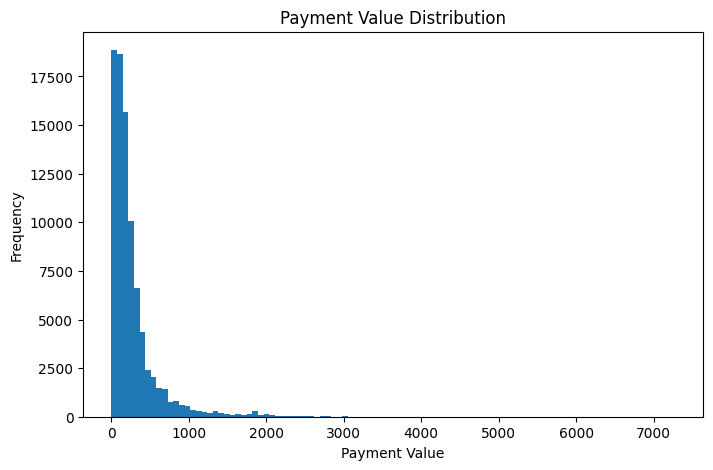

In [119]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['payment_value'], bins=100)
plt.title("Payment Value Distribution")
plt.xlabel("Payment Value")
plt.ylabel("Frequency")
plt.show()

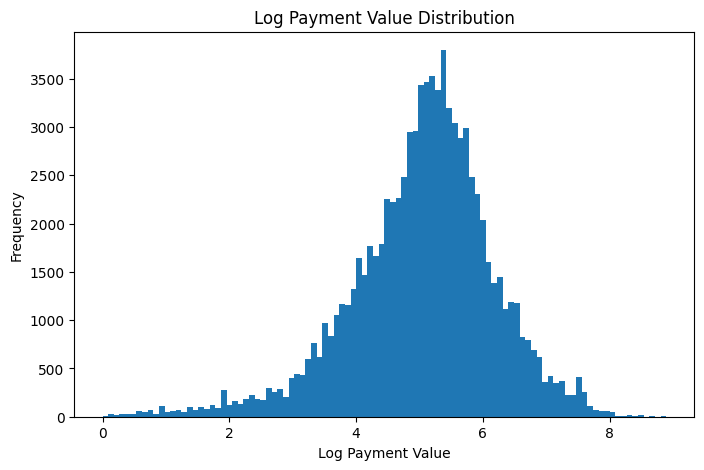

In [120]:
import numpy as np

plt.figure(figsize=(8,5))
plt.hist(np.log1p(df['payment_value']), bins=100)
plt.title("Log Payment Value Distribution")
plt.xlabel("Log Payment Value")
plt.ylabel("Frequency")
plt.show()

In [121]:
percentiles = df['payment_value'].quantile(
    [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
)

print(percentiles)

0.10     37.100
0.20     67.230
0.30    100.470
0.40    135.528
0.50    171.860
0.60    214.090
0.70    272.958
0.80    363.712
0.90    579.930
0.95    852.680
Name: payment_value, dtype: float64


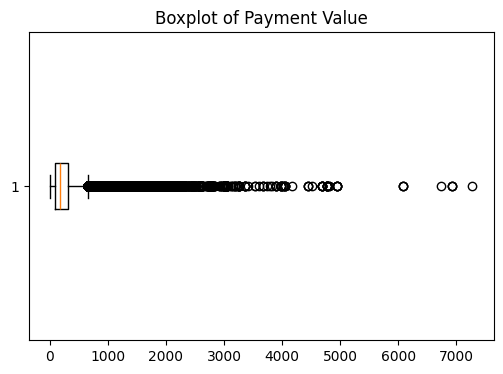

In [122]:
plt.figure(figsize=(6,4))
plt.boxplot(df['payment_value'], vert=False)
plt.title("Boxplot of Payment Value")
plt.show()

In [123]:
def categorize(value):
    if value <= 135:
        return 0
    elif value <= 364:
        return 1
    else:
        return 2

df_final['value_segment'] = df['payment_value'].apply(categorize)

In [124]:
df_final['value_segment'].value_counts(normalize=True)

value_segment
1    0.402961
0    0.397458
2    0.199581
Name: proportion, dtype: float64

In [125]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    objective='multi:softprob',
    num_class=3,
    scale_pos_weight=2,
    random_state=42
)

In [126]:
class_weights = {
    0: 1,
    1: 1,
    2: 2   # give more importance to premium
}

## FINAL Multiclass Model

In [127]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Prepare data
X = df_final.drop(columns=['value_segment'])
y = df_final['value_segment']

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Compute weights
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

# Model
model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    objective='multi:softprob',
    num_class=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train with weights
model.fit(X_train, y_train, sample_weight=sample_weights)

# Predict
y_pred = model.predict(X_test)

# Evaluation
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5030601155408111
              precision    recall  f1-score   support

           0       0.55      0.51      0.53      6865
           1       0.55      0.51      0.53      7151
           2       0.36      0.47      0.41      3467

    accuracy                           0.50     17483
   macro avg       0.49      0.50      0.49     17483
weighted avg       0.52      0.50      0.51     17483



### Tuning xgboost

In [128]:
model = XGBClassifier(
    n_estimators=600,
    max_depth=7,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=1,                # prevents overfitting
    min_child_weight=5,
    objective='multi:softprob',
    num_class=3,
    random_state=42
)

In [129]:
model.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_test, y_test)],
    verbose=False
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [130]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5030601155408111
              precision    recall  f1-score   support

           0       0.55      0.51      0.53      6865
           1       0.55      0.51      0.53      7151
           2       0.36      0.47      0.41      3467

    accuracy                           0.50     17483
   macro avg       0.49      0.50      0.49     17483
weighted avg       0.52      0.50      0.51     17483



In [131]:
y_pred = model.predict(X_test)

In [132]:
import numpy as np
import pandas as pd

# ================================
# 1. ADD NEW FEATURE
# ================================
df_final['cost_per_volume'] = df['total_cost'] / (df['product_volume_cm3'] + 1)


# ================================
# 2. CREATE TARGET (MULTICLASS)
# ================================
def categorize(value):
    if value <= 135:
        return 0   # Normal
    elif value <= 364:
        return 1   # High
    else:
        return 2   # Premium

df_final['value_segment'] = df['payment_value'].apply(categorize)


# ================================
# 3. DEFINE FEATURES & TARGET
# ================================
X = df_final.drop(columns=['value_segment'])
y = df_final['value_segment']


# ================================
# 4. TRAIN TEST SPLIT
# ================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


# ================================
# 5. CLASS WEIGHTS
# ================================
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)


# ================================
# 6. TRAIN MODEL (TUNED XGBOOST)
# ================================
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=600,
    max_depth=7,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=1,
    min_child_weight=5,
    objective='multi:softprob',
    num_class=3,
    random_state=42
)

model.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_test, y_test)],
    verbose=False
)


# ================================
# 7. EVALUATION
# ================================
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.5202768403592061

Classification Report:

              precision    recall  f1-score   support

           0       0.57      0.53      0.55      6865
           1       0.57      0.52      0.55      7151
           2       0.38      0.50      0.43      3467

    accuracy                           0.52     17483
   macro avg       0.51      0.52      0.51     17483
weighted avg       0.53      0.52      0.52     17483



##### Multiclass can only be improved till 5% accuracy, lets keep it secondary for dashboard and use normal classification.

## Model 1 Final - High Value Classification

In [133]:
threshold = df['payment_value'].quantile(0.75)

df_final['high_value'] = (df['payment_value'] > threshold).astype(int)

In [134]:
X = df_final.drop(columns=['value_segment', 'high_value'])
y = df_final['high_value']

In [135]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [136]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

In [137]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train, sample_weight=sample_weights)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [138]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6863810558828576
              precision    recall  f1-score   support

           0       0.83      0.73      0.78     13135
           1       0.40      0.55      0.47      4348

    accuracy                           0.69     17483
   macro avg       0.62      0.64      0.62     17483
weighted avg       0.72      0.69      0.70     17483



### Tuning

In [139]:
y_prob = model.predict_proba(X_test)[:, 1]

In [140]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append((t, precision, recall, f1))

# Convert to DataFrame
import pandas as pd
results_df = pd.DataFrame(results, columns=['threshold', 'precision', 'recall', 'f1'])

print(results_df)

    threshold  precision    recall        f1
0        0.10   0.248969  1.000000  0.398680
1        0.15   0.249684  0.999770  0.399577
2        0.20   0.250476  0.998160  0.400461
3        0.25   0.253113  0.995630  0.403618
4        0.30   0.257074  0.988270  0.408014
5        0.35   0.265424  0.965731  0.416402
6        0.40   0.283491  0.904784  0.431715
7        0.45   0.322920  0.770239  0.455058
8        0.50   0.404057  0.549678  0.465751
9        0.55   0.518464  0.322907  0.397959
10       0.60   0.645344  0.183303  0.285510
11       0.65   0.733871  0.104646  0.183172
12       0.70   0.814332  0.057498  0.107411
13       0.75   0.845588  0.026449  0.051293
14       0.80   0.898305  0.012190  0.024053
15       0.85   1.000000  0.003910  0.007789


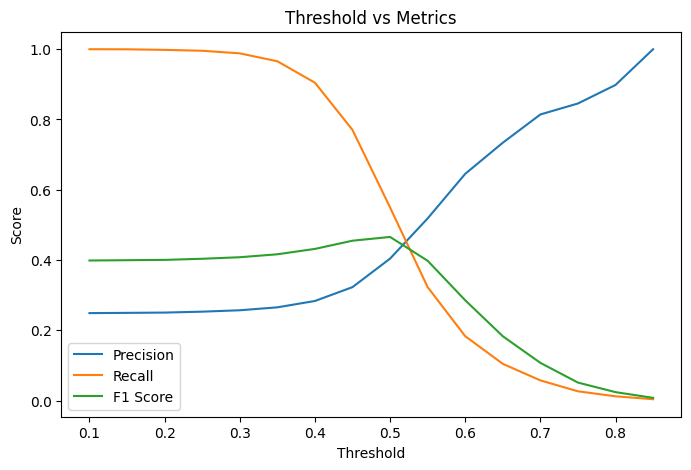

In [141]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(results_df['threshold'], results_df['precision'], label='Precision')
plt.plot(results_df['threshold'], results_df['recall'], label='Recall')
plt.plot(results_df['threshold'], results_df['f1'], label='F1 Score')

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Metrics")
plt.legend()
plt.show()

In [142]:
quantiles = [0.70, 0.75, 0.80, 0.85]

In [143]:
for q in quantiles:
    threshold_val = df['payment_value'].quantile(q)
    
    df_final['high_value'] = (df['payment_value'] > threshold_val).astype(int)
    
    print(f"\nQuantile: {q}")
    print(df_final['high_value'].value_counts(normalize=True))


Quantile: 0.7
high_value
0    0.699999
1    0.300001
Name: proportion, dtype: float64

Quantile: 0.75
high_value
0    0.750014
1    0.249986
Name: proportion, dtype: float64

Quantile: 0.8
high_value
0    0.799995
1    0.200005
Name: proportion, dtype: float64

Quantile: 0.85
high_value
0    0.850034
1    0.149966
Name: proportion, dtype: float64


Enchanments

In [144]:
import numpy as np
import pandas as pd

# ================================
# 1. CREATE TARGET
# ================================
threshold_val = df['payment_value'].quantile(0.75)
df_final['high_value'] = (df['payment_value'] > threshold_val).astype(int)

# ================================
# 2. FEATURES & TARGET
# ================================
X = df_final.drop(columns=['value_segment', 'high_value'], errors='ignore')
y = df_final['high_value'].astype(int)

# ================================
# 3. TRAIN TEST SPLIT
# ================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Safety check
assert set(y_train.unique()) <= {0,1}
assert set(y_test.unique()) <= {0,1}

# ================================
# 4. HANDLE CLASS IMBALANCE
# ================================
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

# ================================
# 5. TRAIN BEST MODEL (XGBOOST)
# ================================
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    min_child_weight=5,
    random_state=42
)

model.fit(X_train, y_train, sample_weight=sample_weights)

# ================================
# 6. CALIBRATION
# ================================
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(model, method='isotonic', cv=3)
calibrated_model.fit(X_train, y_train)

# ================================
# 7. FINAL PREDICTIONS (FIXED)
# ================================
y_prob = calibrated_model.predict_proba(X_test)[:, 1]

# 🔥 IMPORTANT: tuned threshold for better recall
best_threshold = 0.30

y_pred = (y_prob >= best_threshold).astype(int)

# ================================
# 8. FINAL METRICS
# ================================
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.7362580792770119

ROC-AUC: 0.684464581066548

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.85      0.83     13135
           1       0.46      0.39      0.42      4348

    accuracy                           0.74     17483
   macro avg       0.64      0.62      0.63     17483
weighted avg       0.72      0.74      0.73     17483


Confusion Matrix:

[[11196  1939]
 [ 2672  1676]]


In [145]:
for t in [0.25, 0.30, 0.35]:
    y_pred = (y_prob >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred))


Threshold: 0.25
              precision    recall  f1-score   support

           0       0.83      0.68      0.75     13135
           1       0.37      0.57      0.45      4348

    accuracy                           0.66     17483
   macro avg       0.60      0.63      0.60     17483
weighted avg       0.72      0.66      0.68     17483


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.81      0.85      0.83     13135
           1       0.46      0.39      0.42      4348

    accuracy                           0.74     17483
   macro avg       0.64      0.62      0.63     17483
weighted avg       0.72      0.74      0.73     17483


Threshold: 0.35
              precision    recall  f1-score   support

           0       0.79      0.93      0.85     13135
           1       0.54      0.26      0.35      4348

    accuracy                           0.76     17483
   macro avg       0.67      0.59      0.60     17483
weighted avg       0.73 

In [146]:
# ================================
# 9. SAVE MODEL
# ================================
import joblib

model_artifact = {
    "model": calibrated_model,
    "threshold": 0.25
}

joblib.dump(model_artifact, "../models/high_value_model.pkl")

['../models/high_value_model.pkl']

In [147]:
joblib.dump(X_train.columns.tolist(), "../models/high_value_columns.pkl")

['../models/high_value_columns.pkl']

# Model 2 - Delivery Delay Prediction

In [148]:
df_final_new['is_delayed'] = (df['delivery_delay_days'] > 0).astype(int)

print(df_final_new['is_delayed'].value_counts())
print(df_final_new['is_delayed'].value_counts(normalize=True))

is_delayed
0    81809
1     5604
Name: count, dtype: int64
is_delayed
0    0.935891
1    0.064109
Name: proportion, dtype: float64


In [149]:
df_final_new.head()

,payment_sequential,payment_type,payment_installments,payment_value,customer_state,product_category_name,product_weight_g,product_height_cm,product_volume_cm3,approval_time_hours,delivery_delay_days,total_cost,product_density,order_month,is_weekend,log_delivery_time,log_shipping_ratio,price_bucket,high_shipping,is_expensive,is_large_product,high_installments,top_category,is_delayed
0,1,credit_card,1,259.14,SP,toys,491.0,12.0,3648.0,0.271944,-14,308.16,0.134594,10,1,1.609438,0.321163,3,0,1,0,0,1,0
1,1,credit_card,8,382.39,RJ,watches_gifts,440.0,14.0,4284.0,0.663611,-21,194.59,0.102708,6,0,2.639057,0.130401,2,0,1,0,1,1,0
2,1,credit_card,4,249.25,SP,costruction_tools_garden,2200.0,16.0,4096.0,23.934444,-9,81.78,0.537109,2,0,2.397895,0.238919,1,0,0,0,1,0,0
3,1,credit_card,2,27.79,MG,toys,1450.0,3.0,9792.0,0.179722,-23,295.22,0.148080,8,1,2.302585,0.109880,3,0,1,1,0,1,0
4,1,credit_card,1,76.15,SP,toys,300.0,4.0,816.0,0.790833,-13,810.56,0.367647,12,0,2.708050,0.038560,4,0,1,0,0,1,0


In [150]:
df_final_new.describe()

,payment_sequential,payment_installments,payment_value,product_weight_g,product_height_cm,product_volume_cm3,approval_time_hours,delivery_delay_days,total_cost,product_density,order_month,is_weekend,log_delivery_time,log_shipping_ratio,price_bucket,high_shipping,is_expensive,is_large_product,high_installments,top_category,is_delayed
count,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000
mean,1.097400,2.963987,268.788524,2081.968750,16.528275,15178.513539,10.292836,-12.012367,386.536872,0.182799,6.032856,0.225641,2.363521,0.368378,1.982039,0.293869,0.499685,0.499743,0.288424,0.908503,0.064109
std,0.742207,2.794934,344.834902,3734.926025,13.366062,23139.189494,19.754494,8.934977,560.813861,0.353039,3.231184,0.418006,0.634378,0.479195,1.401218,0.455535,0.500003,0.500003,0.453032,0.288316,0.244949
min,1.000000,0.000000,0.000000,2.000000,2.000000,168.000000,0.000000,-30.000000,1.140000,0.000318,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,84.330000,300.000000,8.000000,2856.000000,0.215278,-17.000000,107.720000,0.067200,3.000000,0.000000,1.945910,0.070443,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,1.000000,2.000000,171.860000,700.000000,13.000000,6555.000000,0.344722,-13.000000,184.750000,0.112000,6.000000,0.000000,2.397895,0.200325,2.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,1.000000,4.000000,313.550000,1800.000000,20.000000,18375.000000,14.833056,-7.000000,438.450000,0.191250,8.000000,0.000000,2.772589,0.474425,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,26.000000,24.000000,7274.880000,40425.000000,105.000000,294000.000000,168.000000,30.000000,6738.820000,10.000000,12.000000,1.000000,5.347108,5.329234,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [151]:
df_final_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87413 entries, 0 to 87412
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   payment_sequential     87413 non-null  int64   
 1   payment_type           87413 non-null  category
 2   payment_installments   87413 non-null  int16   
 3   payment_value          87413 non-null  float64 
 4   customer_state         87413 non-null  category
 5   product_category_name  87413 non-null  category
 6   product_weight_g       87413 non-null  float32 
 7   product_height_cm      87413 non-null  float32 
 8   product_volume_cm3     87413 non-null  float64 
 9   approval_time_hours    87413 non-null  float64 
 10  delivery_delay_days    87413 non-null  int64   
 11  total_cost             87413 non-null  float64 
 12  product_density        87413 non-null  float64 
 13  order_month            87413 non-null  int32   
 14  is_weekend             87413 non-null 

In [152]:
df_final_new = df_final_new.drop(columns=['delivery_delay_days'])

In [153]:
df_final_new = df_final_new.drop(columns=[
    'log_delivery_time'
])

In [154]:
X = df_final_new.drop(columns=['is_delayed'])
y = df_final_new['is_delayed']

In [155]:
X = pd.get_dummies(
    X,
    columns=['payment_type', 'customer_state', 'product_category_name'],
    drop_first=True
)

In [156]:
print(X.shape)
print(y.value_counts(normalize=True))

(87413, 117)
is_delayed
0    0.935891
1    0.064109
Name: proportion, dtype: float64


In [157]:
# imbalance ratio
neg = (y == 0).sum()
pos = (y == 1).sum()

scale_pos_weight = neg / pos

print("Scale Pos Weight:", scale_pos_weight)

Scale Pos Weight: 14.598322626695218


In [158]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model_delay = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

model_delay.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [159]:
y_prob = model_delay.predict_proba(X_test)[:, 1]

# start with default threshold
y_pred = (y_prob >= 0.5).astype(int)

In [160]:
from sklearn.metrics import classification_report, roc_auc_score

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

ROC-AUC: 0.7746112906169599

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.84      0.90     16359
           1       0.20      0.57      0.29      1124

    accuracy                           0.82     17483
   macro avg       0.58      0.71      0.60     17483
weighted avg       0.92      0.82      0.86     17483



In [161]:
for t in [0.3, 0.4, 0.5]:
    y_pred = (y_prob >= t).astype(int)
    
    print(f"\nThreshold: {t}")
    from sklearn.metrics import classification_report
    print(classification_report(y_test, y_pred))


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.98      0.52      0.68     16359
           1       0.11      0.83      0.19      1124

    accuracy                           0.54     17483
   macro avg       0.54      0.68      0.43     17483
weighted avg       0.92      0.54      0.65     17483


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.97      0.71      0.82     16359
           1       0.14      0.70      0.24      1124

    accuracy                           0.71     17483
   macro avg       0.56      0.70      0.53     17483
weighted avg       0.92      0.71      0.78     17483


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.97      0.84      0.90     16359
           1       0.20      0.57      0.29      1124

    accuracy                           0.82     17483
   macro avg       0.58      0.71      0.60     17483
weighted avg       0.92   

### Tuning

In [162]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    n_estimators=600,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=2,
    min_child_weight=10,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

model_xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [163]:
from lightgbm import LGBMClassifier

model_lgb = LGBMClassifier(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=8,
    num_leaves=50,
    subsample=0.9,
    colsample_bytree=0.9,
    class_weight='balanced',
    random_state=42
)

model_lgb.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 4480, number of negative: 65450
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006308 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2110
[LightGBM] [Info] Number of data points in the train set: 69930, number of used features: 96
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

,boosting_type,'gbdt'
,num_leaves,50
,max_depth,8
,learning_rate,0.03
,n_estimators,600
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [164]:
from sklearn.metrics import classification_report, roc_auc_score

models = {
    "XGBoost": model_xgb,
    "LightGBM": model_lgb
}

for name, model in models.items():
    print(f"\n===== {name} =====")
    
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.4).astype(int)   # use chosen threshold
    
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print(classification_report(y_test, y_pred))


===== XGBoost =====
ROC-AUC: 0.7844724649049931
              precision    recall  f1-score   support

           0       0.97      0.80      0.88     16359
           1       0.18      0.64      0.28      1124

    accuracy                           0.79     17483
   macro avg       0.57      0.72      0.58     17483
weighted avg       0.92      0.79      0.84     17483


===== LightGBM =====
ROC-AUC: 0.7756955860704622
              precision    recall  f1-score   support

           0       0.97      0.72      0.83     16359
           1       0.15      0.69      0.24      1124

    accuracy                           0.72     17483
   macro avg       0.56      0.70      0.53     17483
weighted avg       0.92      0.72      0.79     17483



In [165]:
from sklearn.calibration import CalibratedClassifierCV

calibrated = CalibratedClassifierCV(model_lgb, method='isotonic', cv=3)
calibrated.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 2987, number of negative: 43633
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004099 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2099
[LightGBM] [Info] Number of data points in the train set: 46620, number of used features: 93
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",LGBMClassifie...subsample=0.9)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,boosting_type,'gbdt'
,num_leaves,50
,max_depth,8
,learning_rate,0.03
,n_estimators,600
,subsample_for_bin,200000


In [166]:
y_prob = model_xgb.predict_proba(X_test)[:, 1]

best_threshold = 0.4

y_pred = (y_prob >= best_threshold).astype(int)

In [167]:
import joblib

delay_artifact = {
    "model": model_xgb,
    "threshold": 0.4
}

joblib.dump(delay_artifact, "../models/delay_model.pkl")

['../models/delay_model.pkl']

In [168]:
joblib.dump(X_train.columns.tolist(), "../models/delay_columns.pkl")

['../models/delay_columns.pkl']

In [169]:
df_final.head()

,payment_installments,payment_sequential,total_cost,log_shipping_ratio,product_weight_g,product_volume_cm3,product_density,product_height_cm,approval_time_hours,delivery_delay_days,log_delivery_time,order_month,is_weekend,price_bucket,high_shipping,is_expensive,is_large_product,high_installments,top_category,value_segment,payment_type_debit_card,payment_type_voucher,payment_type_wallet,customer_state_AL,customer_state_AM,customer_state_AP,customer_state_BA,customer_state_CE,customer_state_DF,customer_state_ES,customer_state_GO,customer_state_MA,customer_state_MG,customer_state_MS,customer_state_MT,customer_state_PA,customer_state_PB,customer_state_PE,customer_state_PI,customer_state_PR,customer_state_RJ,customer_state_RN,customer_state_RO,customer_state_RR,customer_state_RS,customer_state_SC,customer_state_SE,customer_state_SP,customer_state_TO,product_category_name_air_conditioning,product_category_name_art,product_category_name_arts_and_craftmanship,product_category_name_audio,product_category_name_auto,product_category_name_baby,product_category_name_bed_bath_table,product_category_name_books_general_interest,product_category_name_books_imported,product_category_name_books_technical,product_category_name_christmas_supplies,product_category_name_cine_photo,product_category_name_computers,product_category_name_computers_accessories,product_category_name_consoles_games,product_category_name_construction_tools_construction,product_category_name_construction_tools_lights,product_category_name_construction_tools_safety,product_category_name_cool_stuff,product_category_name_costruction_tools_garden,product_category_name_costruction_tools_tools,product_category_name_diapers_and_hygiene,product_category_name_drinks,product_category_name_dvds_blu_ray,product_category_name_electronics,product_category_name_fashio_female_clothing,product_category_name_fashion_bags_accessories,product_category_name_fashion_childrens_clothes,product_category_name_fashion_male_clothing,product_category_name_fashion_shoes,product_category_name_fashion_sport,product_category_name_fashion_underwear_beach,product_category_name_fixed_telephony,product_category_name_flowers,product_category_name_food,product_category_name_food_drink,product_category_name_furniture_bedroom,product_category_name_furniture_decor,product_category_name_furniture_living_room,product_category_name_furniture_mattress_and_upholstery,product_category_name_garden_tools,product_category_name_health_beauty,product_category_name_home_appliances,product_category_name_home_appliances_2,product_category_name_home_comfort_2,product_category_name_home_confort,product_category_name_home_construction,product_category_name_housewares,product_category_name_industry_commerce_and_business,product_category_name_kitchen_dining_laundry_garden_furniture,product_category_name_la_cuisine,product_category_name_luggage_accessories,product_category_name_market_place,product_category_name_music,product_category_name_musical_instruments,product_category_name_office_furniture,product_category_name_party_supplies,product_category_name_perfumery,product_category_name_pet_shop,product_category_name_security_and_services,product_category_name_signaling_and_security,product_category_name_small_appliances,product_category_name_small_appliances_home_oven_and_coffee,product_category_name_sports_leisure,product_category_name_stationery,product_category_name_tablets_printing_image,product_category_name_telephony,product_category_name_toys,product_category_name_unknown,product_category_name_watches_gifts,cost_per_volume,high_value
0,1,1,308.16,0.321163,491.0,3648.0,0.134594,12.0,0.271944,-14,1.609438,10,1,3,0,1,0,0,1,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,

In [170]:
df.head()

,payment_sequential,payment_type,payment_installments,payment_value,customer_state,product_category_name,product_weight_g,product_height_cm,product_volume_cm3,approval_time_hours,delivery_delay_days,total_cost,product_density,order_month,is_weekend,log_delivery_time,log_shipping_ratio,price_bucket,high_shipping,is_expensive,is_large_product,high_installments,top_category
0,1,credit_card,1,259.14,SP,toys,491.0,12.0,3648.0,0.271944,-14,308.16,0.134594,10,1,1.609438,0.321163,3,0,1,0,0,1
1,1,credit_card,8,382.39,RJ,watches_gifts,440.0,14.0,4284.0,0.663611,-21,194.59,0.102708,6,0,2.639057,0.130401,2,0,1,0,1,1
2,1,credit_card,4,249.25,SP,costruction_tools_garden,2200.0,16.0,4096.0,23.934444,-9,81.78,0.537109,2,0,2.397895,0.238919,1,0,0,0,1,0
3,1,credit_card,2,27.79,MG,toys,1450.0,3.0,9792.0,0.179722,-23,295.22,0.148080,8,1,2.302585,0.109880,3,0,1,1,0,1
4,1,credit_card,1,76.15,SP,toys,300.0,4.0,816.0,0.790833,-13,810.56,0.367647,12,0,2.708050,0.038560,4,0,1,0,0,1


In [172]:
df_dashboard.head()

,payment_sequential,payment_type,payment_installments,payment_value,customer_state,product_category_name,product_weight_g,product_height_cm,product_volume_cm3,approval_time_hours,delivery_delay_days,total_cost,product_density,order_month,is_weekend,log_delivery_time,log_shipping_ratio,price_bucket,high_shipping,is_expensive,is_large_product,high_installments,top_category,high_value,is_delayed
0,1,credit_card,1,259.14,SP,toys,491.0,12.0,3648.0,0.271944,-14,308.16,0.134594,10,1,1.609438,0.321163,3,0,1,0,0,1,0,0
1,1,credit_card,8,382.39,RJ,watches_gifts,440.0,14.0,4284.0,0.663611,-21,194.59,0.102708,6,0,2.639057,0.130401,2,0,1,0,1,1,1,0
2,1,credit_card,4,249.25,SP,costruction_tools_garden,2200.0,16.0,4096.0,23.934444,-9,81.78,0.537109,2,0,2.397895,0.238919,1,0,0,0,1,0,0,0
3,1,credit_card,2,27.79,MG,toys,1450.0,3.0,9792.0,0.179722,-23,295.22,0.148080,8,1,2.302585,0.109880,3,0,1,1,0,1,0,0
4,1,credit_card,1,76.15,SP,toys,300.0,4.0,816.0,0.790833,-13,810.56,0.367647,12,0,2.708050,0.038560,4,0,1,0,0,1,0,0


In [174]:
import pandas as pd

# Use your Data 2
df_dashboard = df.copy()

# =========================
# 🔥 SAFETY CHECKS
# =========================

# Ensure targets exist
if "high_value" not in df_dashboard.columns:
    df_dashboard["high_value"] = (
        df_dashboard["payment_value"] > df_dashboard["payment_value"].quantile(0.75)
    ).astype(int)

if "is_delayed" not in df_dashboard.columns:
    df_dashboard["is_delayed"] = (
        df_dashboard["delivery_delay_days"] > 0
    ).astype(int)

# =========================
# 🔥 CREATE DASHBOARD FEATURES
# =========================

# Delivery time approximation (since no timestamps)
df_dashboard["delivery_time_days"] = df_dashboard["delivery_delay_days"].abs()

# Revenue bucket labels (for charts)
df_dashboard["value_segment"] = pd.cut(
    df_dashboard["payment_value"],
    bins=[0, 100, 300, 700, 10000],
    labels=["Low", "Medium", "High", "Premium"]
)

# =========================
# 🔥 KEEP IMPORTANT COLUMNS
# =========================

cols = [
    "payment_value",
    "customer_state",
    "payment_type",
    "product_category_name",
    "order_month",

    "delivery_delay_days",
    "delivery_time_days",

    "high_value",
    "is_delayed",

    "value_segment",

    "total_cost",
    "product_volume_cm3",
    "product_weight_g",
    "product_density",

    "price_bucket",
    "high_shipping",
    "is_expensive",
    "is_large_product"
]

df_dashboard = df_dashboard[cols]

# =========================
# 💾 SAVE
# =========================

df_dashboard.to_csv("../data/processed/dashboard_dataset.csv", index=False)

print("Dashboard dataset ready:", df_dashboard.shape)

Dashboard dataset ready: (87413, 18)
